# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
!pip install -U huggingface_hub

In [2]:
from huggingface_hub import login

login() 

In [2]:
!pip install datasets

   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 11.0 MB/s  0:00:00
   ---------------------------------------- 0.0/796.8 kB ? eta -:--:--
   ---------------------------------------- 796.8/796.8 kB 17.4 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 20.0 MB/s  0:00:00

  Attempting uninstall: dill

    Found existing installation: dill 0.4.0

   ----------- ---------------------------- 2/7 [dill]
    Uninstalling dill-0.4.0:
   ----------- ---------------------------- 2/7 [dill]
      Successfully uninstalled dill-0.4.0
   ----------- ---------------------------- 2/7 [dill]
   ----------- ---------------------------- 2/7 [dill]
   ----------- ---------------------------- 2/7 [dill]
  Attempting uninstall: click
   ----------- ---------------------------- 2/7 [dill]
    Found existing installation: click 8.2.1
   ----

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [6]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [7]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

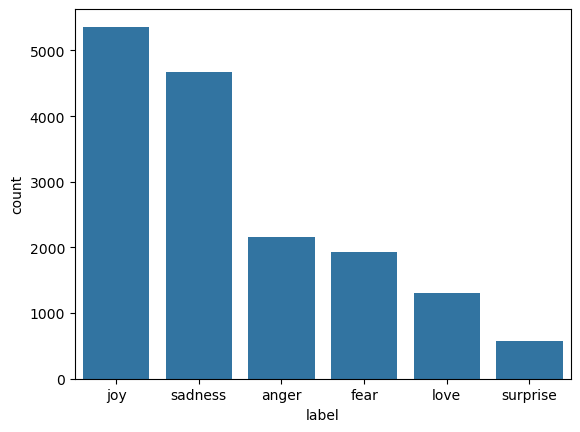

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [9]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.1606 - loss: 1.9350 - val_accuracy: 0.1895 - val_loss: 1.7784
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.1531 - loss: 1.8079 - val_accuracy: 0.0635 - val_loss: 1.8248
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.1614 - loss: 1.7846 - val_accuracy: 0.1805 - val_loss: 1.7582
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.1506 - loss: 1.7927 - val_accuracy: 0.1265 - val_loss: 1.7879
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.1391 - loss: 1.8461 - val_accuracy: 0.2645 - val_loss: 1.7408
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1408 - loss: 1.8098 - val_accuracy: 0.0845 - val_loss: 1.8050
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1369 - loss: 1.8029 - val_accuracy: 0.2675 - val_loss: 1.7725
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1420 - loss: 1.8028 - 

### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 125ms/step - accuracy: 0.1665 - loss: 1.7951 - val_accuracy: 0.3395 - val_loss: 1.7636
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.1584 - loss: 1.7937 - val_accuracy: 0.3475 - val_loss: 1.7815
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 125ms/step - accuracy: 0.1720 - loss: 1.7929 - val_accuracy: 0.0820 - val_loss: 1.7975
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3395 - loss: 1.7636
LSTM Loss: 1.7635759115219116
LSTM Accuracy: 0.3395000100135803


### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 110ms/step - accuracy: 0.1570 - loss: 1.7961 - val_accuracy: 0.2890 - val_loss: 1.7825
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.1546 - loss: 1.7947 - val_accuracy: 0.0360 - val_loss: 1.7814
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 97ms/step - accuracy: 0.1557 - loss: 1.7939 - val_accuracy: 0.1380 - val_loss: 1.7849
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2890 - loss: 1.7825
GRU Loss: 1.7824501991271973
GRU Accuracy: 0.289000004529953


### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.763576,0.3395
2,GRU,1.782450,0.2890
0,RNN,1.740814,0.2645


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train & Evaluate Advanced Bidirectional GRU

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 264ms/step - accuracy: 0.5814 - loss: 1.0094 - val_accuracy: 0.8520 - val_loss: 0.4911
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - accuracy: 0.9104 - loss: 0.2551 - val_accuracy: 0.9110 - val_loss: 0.2703
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 302ms/step - accuracy: 0.9423 - loss: 0.1628 - val_accuracy: 0.9200 - val_loss: 0.2552
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 315ms/step - accuracy: 0.9572 - loss: 0.1197 - val_accuracy: 0.9145 - val_loss: 0.2542
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 149s 299ms/step - accuracy: 0.9662 - loss: 0.0984 - val_accuracy: 0.9210 - val_loss: 0.2258
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 210s 315ms/step - accuracy: 0.9736 - loss: 0.0756 - val_accuracy: 0.9295 - val_loss: 0.2562
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 153s 306ms/step - accuracy: 0.9804 - loss: 0.0562 - val_accuracy: 0.9260 - val_loss: 0.2383
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 208s 318ms/step - accuracy: 0.9833 -

In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9210 - loss: 0.2258
BiGRU Loss: 0.2257886677980423
BiGRU Accuracy: 0.9210000038146973


## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [ ]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step


<Axes: >

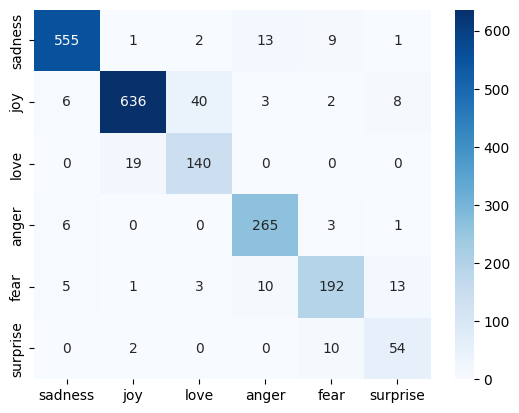

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)